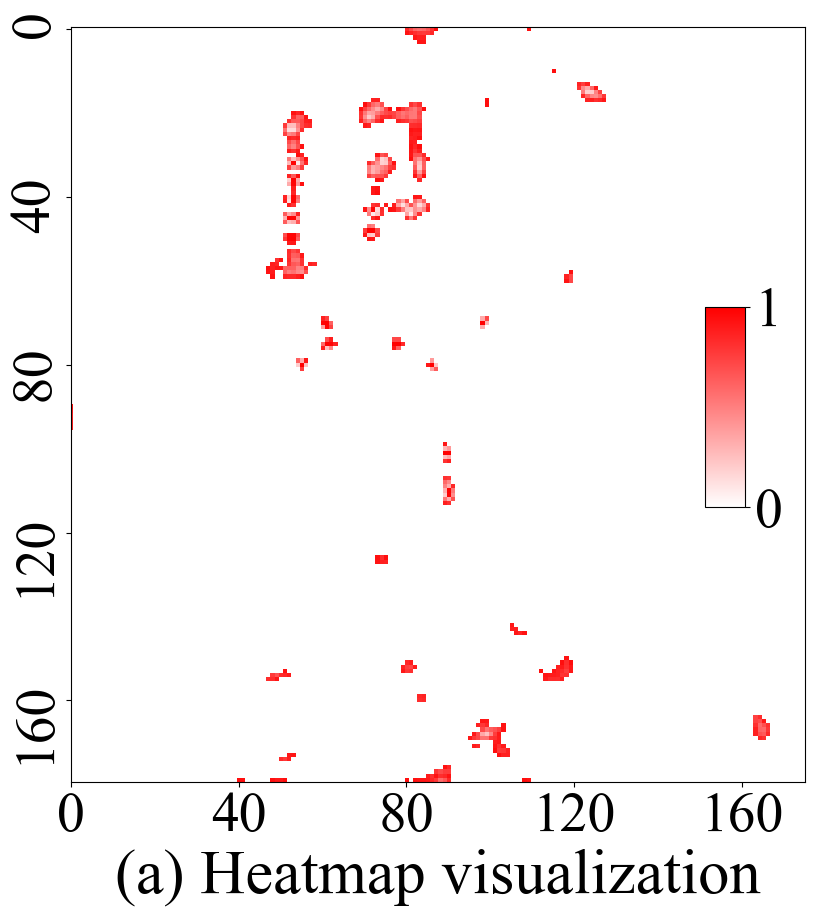

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from matplotlib import colors

'''
def custom_cmap(value):
    # 自定义颜色映射函数
    # 根据特征值范围，返回对应的颜色
    # 返回的颜色可以是RGB元组或HTML颜色代码
    # 这里只是一个示例，你可以根据自己的需求定义更复杂的映射函数
    if value < 0.98:
        return (1, 0, 0)  # 红色
    else:
        return (1, 1, 1)  # 白色
'''

data = torch.load('./file.pth',map_location=torch.device('cpu'))
data = data[2].squeeze(0)
data = data.cpu()
feature_map = data.numpy()
# 标准化特征值到 [0, 1] 范围

start_color = 'white'
end_color = 'red'

# 创建颜色映射对象
cmap = colors.LinearSegmentedColormap.from_list('my_cmap', [start_color, end_color])

normalized_map = (feature_map - np.min(feature_map)) / (np.max(feature_map) - np.min(feature_map))
for i in range(0,180):
    for j in range(0,180):
        if normalized_map[i][j] <= 0.95:
            normalized_map[i][j] = 0
        elif (normalized_map[i][j] >= 0.95 and normalized_map[i][j] <= 0.98):
            normalized_map[i][j] = normalized_map[i][j] - (normalized_map[i][j]-0.95)* 30


#new
fig,ax=plt.subplots(figsize=(10, 10), dpi=100)
ax.tick_params(axis='x',labelsize=40)
ax.tick_params(axis='y',labelsize=40,rotation=90)
ax.set_xticks(np.arange(0,175, 40))
ax.set_yticks(np.arange(0,175, 40))
ax.set_xlim(0, 175)
# ax.set_ylim(0, 175) #这里设置了的话图就倒过来了
plt.rcParams["font.family"] = "Times New Roman"
plt.xlabel('(a) Heatmap visualization',fontsize=45)

# 可视化特征图
plt.imshow(normalized_map, cmap=cmap)
cbar_ax = fig.add_axes([0.78, 0.40, 0.04, 0.2])#设置颜色条的位置和长款
aaa=plt.colorbar(cax=cbar_ax,ticks=[0, 1], fraction=0.05, aspect=4.0)
aaa.ax.tick_params(labelsize=40)#设置颜色条的字体大小
plt.savefig('./dongji_1.png',bbox_inches='tight')
plt.show()